In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

ecg = pd.read_csv('ecg_data_summary.csv',
                  header=None, names=['ts_us', 'adc', 'flag'])
ecg['time_s'] = (ecg.ts_us - ecg.ts_us.iloc[0]) / 1e6
fs_estimate = 1e6 / ecg.ts_us.diff().mean()

# Saturation analytics
n_rail = ((ecg.adc == 0) | (ecg.adc == 4095)).sum()
pct_rail = n_rail / len(ecg) * 100
print(f"Sampling rate: {fs_estimate:.0f} Hz (dt jitter: {ecg.ts_us.diff().std():.1f} µs)")
print(f"Total samples: {len(ecg)}, Duration: {ecg.time_s.max():.1f} s")
print(f"Railed samples: {n_rail} ({pct_rail:.1f}%)")
print(f"→ Recording UNUSABLE for QRS/HR analysis")
print(f"→ Root cause: AD8232 REF pin DC bias missing (see Section 4.3 of summary)")

# Per-second saturation (for the C-panel figure)
ecg['sec'] = ecg.time_s.astype(int)
# Per-second saturation (warning-free version)
sat_per_sec = ecg.groupby('sec')['adc'].apply(
    lambda s: ((s == 0) | (s == 4095)).mean() * 100
)
sat_per_sec.to_csv('ecg_saturation_per_second.csv')

Sampling rate: 250 Hz (dt jitter: 0.0 µs)
Total samples: 139766, Duration: 559.1 s
Railed samples: 98025 (70.1%)
→ Recording UNUSABLE for QRS/HR analysis
→ Root cause: AD8232 REF pin DC bias missing (see Section 4.3 of summary)


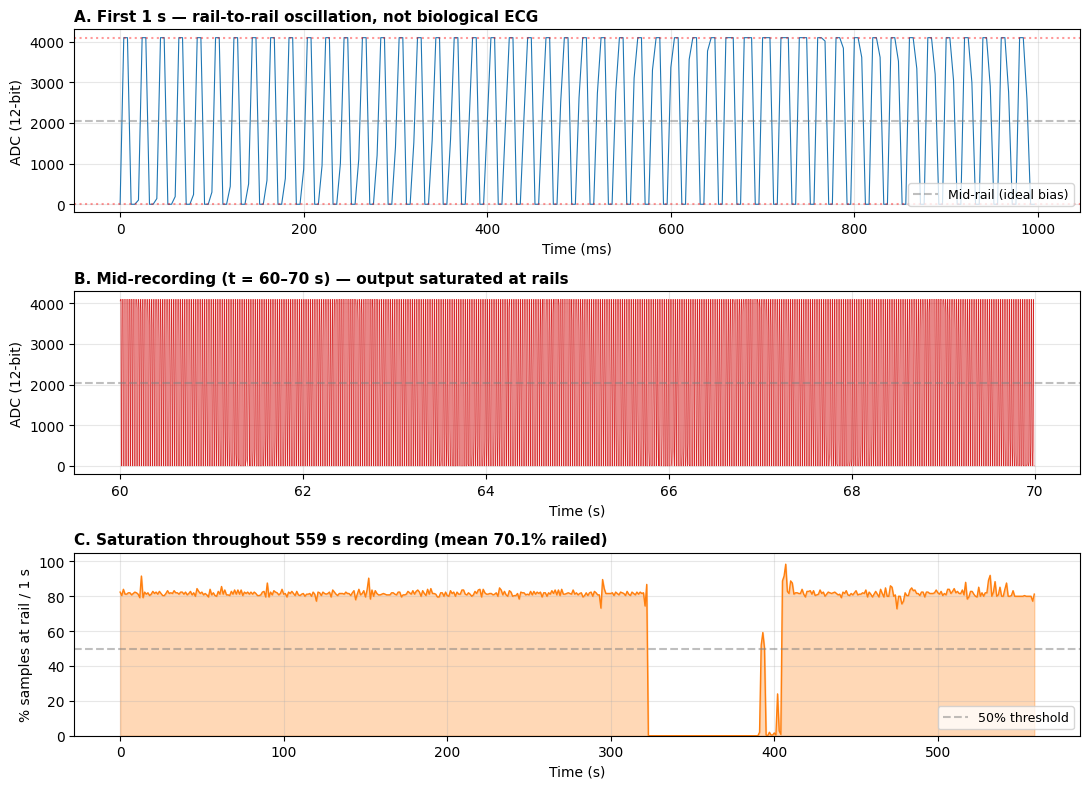

In [3]:
# Cell: Plot ECG diagnostic figure (3 panels)
from pathlib import Path
Path('figures').mkdir(exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), gridspec_kw={'height_ratios': [1, 1, 1]})

# Panel A: first 1 second
mask_settle = ecg.time_s < 1.0
axes[0].plot(ecg.loc[mask_settle, 'time_s'] * 1000, ecg.loc[mask_settle, 'adc'],
             linewidth=0.8, color='#1f77b4')
axes[0].axhline(2048, color='gray', linestyle='--', alpha=0.5, label='Mid-rail (ideal bias)')
axes[0].axhline(0, color='red', linestyle=':', alpha=0.4)
axes[0].axhline(4095, color='red', linestyle=':', alpha=0.4)
axes[0].set_xlabel('Time (ms)'); axes[0].set_ylabel('ADC (12-bit)')
axes[0].set_title('A. First 1 s — rail-to-rail oscillation, not biological ECG',
                  fontsize=11, fontweight='bold', loc='left')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3); axes[0].set_ylim(-200, 4300)

# Panel B: 10-second window in middle
mask_mid = (ecg.time_s >= 60) & (ecg.time_s < 70)
axes[1].plot(ecg.loc[mask_mid, 'time_s'], ecg.loc[mask_mid, 'adc'],
             linewidth=0.4, color='#d62728')
axes[1].axhline(2048, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('ADC (12-bit)')
axes[1].set_title('B. Mid-recording (t = 60–70 s) — output saturated at rails',
                  fontsize=11, fontweight='bold', loc='left')
axes[1].grid(True, alpha=0.3); axes[1].set_ylim(-200, 4300)

# Panel C: per-second saturation
axes[2].plot(sat_per_sec.index, sat_per_sec.values, color='#ff7f0e', linewidth=1.0)
axes[2].fill_between(sat_per_sec.index, sat_per_sec.values, alpha=0.3, color='#ff7f0e')
axes[2].axhline(50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('% samples at rail / 1 s')
axes[2].set_title(f'C. Saturation throughout 559 s recording (mean {pct_rail:.1f}% railed)',
                  fontsize=11, fontweight='bold', loc='left')
axes[2].legend(loc='lower right', fontsize=9)
axes[2].grid(True, alpha=0.3); axes[2].set_ylim(0, 105)

plt.tight_layout()
plt.savefig('figures/fig_ecg_diagnostic.png', dpi=180, bbox_inches='tight')
plt.show()